# Kalibrasi dan Runtime Hybrid Tanpa LLM
Notebook ini menjalankan pipeline hybrid tanpa LLM secara end-to-end melalui CLI/service proyek. Progress tahap utama ditampilkan dengan `tqdm`.


In [13]:
from pathlib import Path
import json
import subprocess
import sys

from IPython.display import display
import polars as pl
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "services").is_dir():
            return candidate
    raise FileNotFoundError("Root proyek tidak ditemukan")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config
from services.artifact_service import ArtifactService

artifact_service = ArtifactService()
PROJECT_ROOT


WindowsPath('E:/School/tugas-akhir/project')

## 1. Konfigurasi Eksekusi

In [14]:
EXPERIMENT_ID = "hybrid_indobert_socal_manual"
EXPERIMENT_DIR = Path(config.EXPERIMENT_CONFIG["artifact_root"]) / EXPERIMENT_ID
MODEL_DIR = EXPERIMENT_DIR / "model"
RUNTIME_DIR = EXPERIMENT_DIR / "runtime"

RUN_BUILD_TRAINING_DATASET = True
RUN_BUILD_RAW_CANDIDATE_SCHEMA = False
RUN_CREATE_FIXED_SPLIT = True
RUN_TRAIN_MODEL = not (MODEL_DIR / "config.json").exists()
RUN_CALIBRATE = True
RUN_RUNTIME_WITHOUT_LLM = True
RUNTIME_LIMIT = None

print("Experiment dir:", EXPERIMENT_DIR)
print("Model exists:", (MODEL_DIR / "config.json").exists())
print("RUN_TRAIN_MODEL:", RUN_TRAIN_MODEL)
print("RUNTIME_LIMIT:", RUNTIME_LIMIT)

Experiment dir: E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual
Model exists: True
RUN_TRAIN_MODEL: False
RUNTIME_LIMIT: None


## 2. Jalankan Pipeline End-to-End

In [15]:
runtime_command = [
    sys.executable,
    "main.py",
    "run-without-llm",
    "--model-dir",
    str(MODEL_DIR),
    "--calibration-artifact",
    str(EXPERIMENT_DIR / "calibration_artifact.json"),
    "--fusion-policy",
    str(EXPERIMENT_DIR / "fusion_policy.json"),
    "--output-dir",
    str(RUNTIME_DIR),
]
if RUNTIME_LIMIT is not None:
    runtime_command.extend(["--limit", str(RUNTIME_LIMIT)])

stages = [
    (
        "build-training-dataset",
        RUN_BUILD_TRAINING_DATASET,
        [sys.executable, "main.py", "build-training-dataset"],
    ),
    (
        "build-raw-candidate-schema",
        RUN_BUILD_RAW_CANDIDATE_SCHEMA,
        [sys.executable, "main.py", "build-raw-candidate-schema"],
    ),
    (
        "create-fixed-group-split",
        RUN_CREATE_FIXED_SPLIT,
        [sys.executable, "main.py", "create-fixed-group-split"],
    ),
    (
        "train-indobert",
        RUN_TRAIN_MODEL,
        [sys.executable, "main.py", "train-indobert", "--experiment-id", EXPERIMENT_ID],
    ),
    (
        "calibrate-indobert",
        RUN_CALIBRATE,
        [sys.executable, "main.py", "calibrate-indobert", "--experiment-dir", str(EXPERIMENT_DIR)],
    ),
    (
        "run-without-llm",
        RUN_RUNTIME_WITHOUT_LLM,
        runtime_command,
    ),
]

completed_stages = []
for stage_name, enabled, command in tqdm(stages, desc="Pipeline tanpa LLM", unit="stage"):
    if not enabled:
        tqdm.write(f"SKIP {stage_name}")
        completed_stages.append({"stage": stage_name, "status": "skipped"})
        continue

    tqdm.write(f"RUN  {stage_name}")
    tqdm.write(" ".join(str(part) for part in command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
    completed_stages.append({"stage": stage_name, "status": "done"})

completed_stages



Pipeline tanpa LLM:   0%|          | 0/6 [00:00<?, ?stage/s]

RUN  build-training-dataset
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py build-training-dataset


Pipeline tanpa LLM:  17%|█▋        | 1/6 [00:00<00:01,  2.51stage/s]

SKIP build-raw-candidate-schema
RUN  create-fixed-group-split
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py create-fixed-group-split


Pipeline tanpa LLM:  50%|█████     | 3/6 [00:01<00:01,  1.64stage/s]

SKIP train-indobert
RUN  calibrate-indobert
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py calibrate-indobert --experiment-dir E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual


Pipeline tanpa LLM:  83%|████████▎ | 5/6 [00:23<00:05,  5.89s/stage]

RUN  run-without-llm
e:\Software\laragon\bin\python\python-3.13.11-amd64\python.exe main.py run-without-llm --model-dir E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual\model --calibration-artifact E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual\calibration_artifact.json --fusion-policy E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual\fusion_policy.json --output-dir E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual\runtime


Pipeline tanpa LLM: 100%|██████████| 6/6 [12:34<00:00, 125.81s/stage]


[{'stage': 'build-training-dataset', 'status': 'done'},
 {'stage': 'build-raw-candidate-schema', 'status': 'skipped'},
 {'stage': 'create-fixed-group-split', 'status': 'done'},
 {'stage': 'train-indobert', 'status': 'skipped'},
 {'stage': 'calibrate-indobert', 'status': 'done'},
 {'stage': 'run-without-llm', 'status': 'done'}]

## 3. Cek Artifact Utama

In [16]:
artifact_paths = {
    "training_dataset": config.TRAINING_DATASET_PATH,
    "training_dataset_with_split": config.TRAINING_DATASET_WITH_SPLIT_PATH,
    "training_manifest": config.ARTIFACTS / "training_dataset_manifest.json",
    "split_manifest": config.FIXED_SPLIT_MANIFEST_PATH,
    "model_dir": MODEL_DIR,
    "model_manifest": EXPERIMENT_DIR / "model_manifest.json",
    "calibration_artifact": EXPERIMENT_DIR / "calibration_artifact.json",
    "fusion_policy": EXPERIMENT_DIR / "fusion_policy.json",
    "metrics": EXPERIMENT_DIR / "metrics.json",
    "runtime_predictions_parquet": RUNTIME_DIR / "scenario_without_llm_predictions.parquet",
    "runtime_predictions_csv": RUNTIME_DIR / "scenario_without_llm_predictions.csv",
    "golden_non_train_predictions": EXPERIMENT_DIR / "golden_non_train_predictions.parquet",
    "golden_all_predictions": EXPERIMENT_DIR / "golden_all_predictions.parquet",
    "runtime_summary": RUNTIME_DIR / "scenario_without_llm_summary.json",
}

artifact_df = pl.DataFrame(
    [
        {"artifact": name, "path": str(path), "exists": Path(path).exists()}
        for name, path in artifact_paths.items()
    ]
)
display(artifact_df)



artifact,path,exists
str,str,bool
"""training_dataset""","""E:\School\tugas-akhir\project\…",true
"""training_dataset_with_split""","""E:\School\tugas-akhir\project\…",true
"""training_manifest""","""E:\School\tugas-akhir\project\…",true
"""split_manifest""","""E:\School\tugas-akhir\project\…",true
"""model_dir""","""E:\School\tugas-akhir\project\…",true
…,…,…
"""runtime_predictions_parquet""","""E:\School\tugas-akhir\project\…",true
"""runtime_predictions_csv""","""E:\School\tugas-akhir\project\…",true
"""golden_non_train_predictions""","""E:\School\tugas-akhir\project\…",true


## 4. Manifest, Calibration, Policy, dan Metrics

In [17]:
def load_json_if_exists(path: Path):
    if not path.exists():
        print(f"Belum ada: {path}")
        return None
    return json.loads(path.read_text(encoding=config.ENCODING))

training_manifest = load_json_if_exists(config.ARTIFACTS / "training_dataset_manifest.json")
split_manifest = load_json_if_exists(config.FIXED_SPLIT_MANIFEST_PATH)
calibration_artifact = load_json_if_exists(EXPERIMENT_DIR / "calibration_artifact.json")
fusion_policy = load_json_if_exists(EXPERIMENT_DIR / "fusion_policy.json")
metrics = load_json_if_exists(EXPERIMENT_DIR / "metrics.json")
runtime_summary = load_json_if_exists(RUNTIME_DIR / "scenario_without_llm_summary.json")


## 5. Preview Output Runtime

In [18]:
predictions_path = RUNTIME_DIR / "scenario_without_llm_predictions.parquet"
if predictions_path.exists():
    predictions_df = pl.read_parquet(predictions_path)
    display(predictions_df.head(20))

    if {"final_sentiment", "needs_review"}.issubset(set(predictions_df.columns)):
        display(
            predictions_df
            .group_by(["final_sentiment", "needs_review"])
            .len()
            .sort(["final_sentiment", "needs_review"])
        )
else:
    print("Runtime predictions belum tersedia:", predictions_path)


text_id,original_text,processed_text,bert_label,bert_prob_negatif,bert_prob_netral,bert_prob_positif,bert_confidence,bert_margin,bert_entropy,rule_contract_version,rule_resource_version,rule_label,rule_score,rule_confidence,rule_status,rule_positive_score,rule_negative_score,rule_positive_count,rule_negative_count,rule_hits,rule_neutral_hits,rule_phrase_hits,rule_word_hits,rule_modifier_hits,rule_evidence,rule_explanation,cross_method_conflict,confidence_uncertainty,margin_uncertainty,routing_uncertainty_score,fusion_action,fusion_reason,final_sentiment,needs_review,source_url,source_type,…,label_status,source_id,dataset_tier,inclusion_status,verification_status,evidence_support_score,parent_text_id,decision_note,raw_source_file,raw_domain,content_status,query_group,query,raw_title,raw_text_length,location_source,location_match,is_specific_location,blacklist_status,blacklist_reason_codes,normalized_source_url,blacklist_is_excluded,base_text_id,sentence_index,sentence_count,candidate_generation_method,source_text_length,candidate_text_length,bert_label_id,bert_logit_negatif,bert_logit_netral,bert_logit_positif,bert_temperature,normalized_entropy,uncertainty_weight_wc,uncertainty_weight_wm,uncertainty_weight_wd
str,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,str,f64,f64,i64,i64,str,str,str,str,str,str,str,bool,f64,f64,f64,str,str,str,bool,str,str,…,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,i64,str,str,bool,str,str,str,bool,str,i64,i64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""RAW-0003#01""","""OIS POWER on Instagram: ""#PLTS…","""ois power on instagram pembang…","""netral""",0.109892,0.829377,0.060731,0.829377,0.719485,0.516975,"""2.0.0""","""socal_metadata=1.1.0;socal_wor…","""netral""",0.0,0.0,"""unknown""",0.0,0.0,0,0,"""""","""""","""""","""""","""""","""{""method"": ""SO-CAL-inspired"", …","""Tidak ada rule sentimen yang d…",false,0.170623,0.280515,0.169466,"""bert_rule_invalid""","""Rule weak/unknown/tanpa eviden…","""netral""",false,"""https://www.instagram.com/reel…","""social_media""",…,"""unlabeled""","""RAW-SRC-0003""","""B_review_queue""","""review_required_before_core""","""perlu_verifikasi""",0.9,"""RAW-0003""","""social_domain_review""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik""…","""OIS POWER | #PLTS #PanelSurya …",371,"""query""","""sambas""",true,"""clear""","""[]""","""https://instagram.com/reel/DY0…",false,"""RAW-0003""",1,2,"""sentence_split""",311,132,1,-1.067125,3.012245,-2.264094,2.018316,0.516975,0.5,0.3,0.2
"""RAW-0003#02""","""Instagram · ois_power 6 suka ·…","""instagram ois power 6 suka 1 b…","""netral""",0.101464,0.842259,0.056277,0.842259,0.740796,0.490326,"""2.0.0""","""socal_metadata=1.1.0;socal_wor…","""netral""",0.0,0.0,"""unknown""",0.0,0.0,0,0,"""""","""""","""""","""""","""""","""{""method"": ""SO-CAL-inspired"", …","""Tidak ada rule sentimen yang d…",false,0.157741,0.259204,0.156632,"""bert_rule_invalid""","""Rule weak/unknown/tanpa eviden…","""netral""",false,"""https://www.instagram.com/reel…","""social_media""",…,"""unlabeled""","""RAW-SRC-0003""","""B_review_queue""","""review_required_before_core""","""perlu_verifikasi""",0.9,"""RAW-0003""","""social_domain_review""","""dataset_20260627T094855Z.json""","""www.instagram.com""","""success""","""issue:benefit""","""""PLTS"" ""hemat tagihan listrik""…","""OIS POWER | #PLTS #PanelSurya …",371,"""query""","""sambas""",true,"""clear""","""[]""","""https://instagram.com/reel/DY0…",false,"""RAW-0003""",2,2,"""sentence_split""",311,178,1,-1.181118,3.090415,-2.370763,2.018316,0.490326,0.5,0.3,0.2
"""RAW-0004#01""","""TEKNIK LISTRIK on Instagram: ""…","""teknik listrik on instagram pa…","""netral""",0.112831,0.803873,0.083295,0.803873,0.691042,0.572265,"""2.0.0""","""socal_metadata=1.1.0;socal_wor…","""netral""",0.0,0.0,"""unknown""",0.0,0.0,0,0,"""""","""""","""""","""""","""""","""{""method"": ""SO-CAL-inspired"", …","""Tid

final_sentiment,needs_review,len
str,bool,u32
"""negatif""",false,3001
"""negatif""",true,429
"""netral""",false,4857
"""netral""",true,756
"""positif""",false,6962
"""positif""",true,462


## 6. Helper Visualisasi

In [19]:
import matplotlib.pyplot as plt

LABEL_ORDER = ["negatif", "netral", "positif"]


def counts_from_series(values):
    counts = {}
    for value in values:
        key = str(value)
        counts[key] = counts.get(key, 0) + 1
    return counts


def plot_count_bar(ax, counts, title, xlabel="Kategori", ylabel="Jumlah", order=None):
    labels = list(order or counts.keys())
    values = [counts.get(label, 0) for label in labels]
    ax.bar(labels, values, color="#4c78a8")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=25)
    for index, value in enumerate(values):
        ax.text(index, value, str(value), ha="center", va="bottom", fontsize=9)


def plot_confusion_matrix(ax, matrix, title):
    values = [
        [int(matrix.get(actual, {}).get(predicted, 0)) for predicted in LABEL_ORDER]
        for actual in LABEL_ORDER
    ]
    image = ax.imshow(values, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=25, ha="right")
    ax.set_yticks(range(len(LABEL_ORDER)), LABEL_ORDER)
    threshold = max([item for row in values for item in row] or [0]) / 2
    for row_index, row in enumerate(values):
        for col_index, value in enumerate(row):
            color = "white" if value > threshold else "black"
            ax.text(col_index, row_index, str(value), ha="center", va="center", color=color)
    return image


def component_metric_table(metrics_payload):
    rows = []
    for component, payload in (metrics_payload or {}).items():
        rows.append(
            {
                "component": component,
                "accuracy": float(payload.get("accuracy", 0.0)),
                "balanced_accuracy": float(payload.get("balanced_accuracy", 0.0)),
                "macro_f1": float(payload.get("macro_f1", 0.0)),
                "weighted_f1": float(payload.get("weighted_f1", 0.0)),
            }
        )
    return rows


## 7. Confusion Matrix Golden dan Ringkasan Performa


Confusion matrix memakai golden_all_audit agar sebaran lebih besar. Metrik final tetap mengacu pada test_after_policy_frozen.


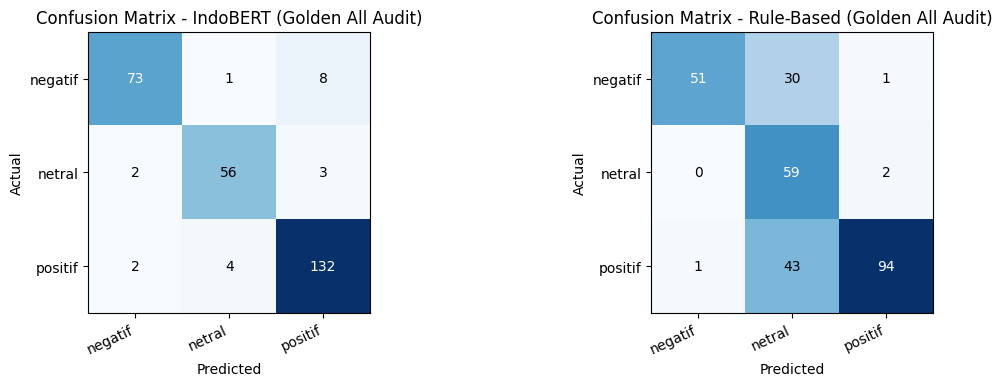

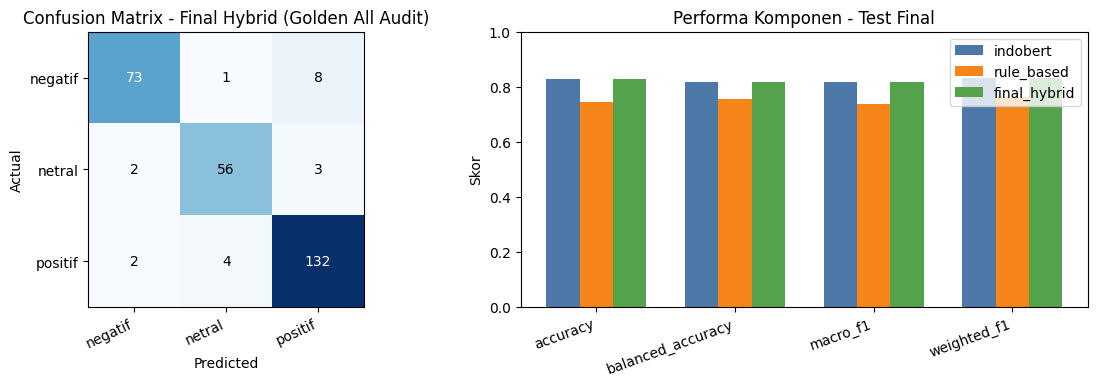

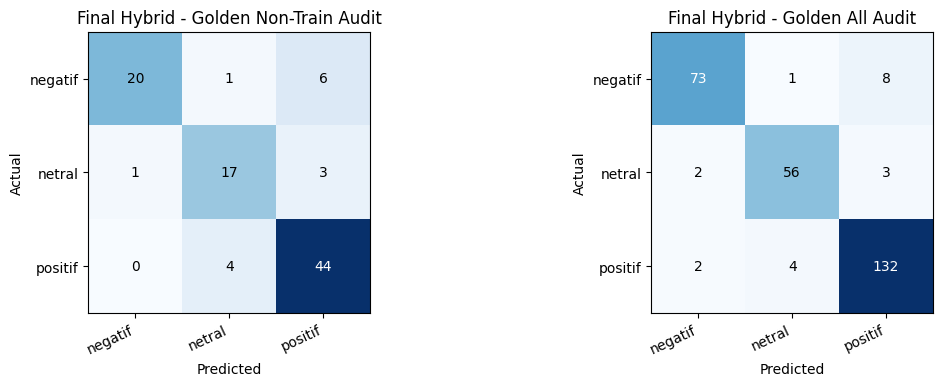

In [20]:
if metrics is None or "test_after_policy_frozen" not in metrics:
    print("metrics.json belum tersedia. Jalankan tahap calibrate-indobert lebih dulu.")
else:
    test_metrics = metrics["test_after_policy_frozen"]
    matrix_key = "golden_all_audit" if "golden_all_audit" in metrics else "test_after_policy_frozen"
    matrix_metrics = metrics[matrix_key]
    matrix_title_suffix = "Golden All Audit" if matrix_key == "golden_all_audit" else "Test"

    if matrix_key == "golden_all_audit":
        print(
            "Confusion matrix memakai golden_all_audit agar sebaran lebih besar. "
            "Metrik final tetap mengacu pada test_after_policy_frozen."
        )
    else:
        print(
            "golden_all_audit belum tersedia. Jalankan ulang calibrate-indobert "
            "untuk memakai seluruh golden dataset pada visualisasi confusion matrix."
        )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_confusion_matrix(
        axes[0],
        matrix_metrics["indobert"]["confusion_matrix"],
        f"Confusion Matrix - IndoBERT ({matrix_title_suffix})",
    )
    plot_confusion_matrix(
        axes[1],
        matrix_metrics["rule_based"]["confusion_matrix"],
        f"Confusion Matrix - Rule-Based ({matrix_title_suffix})",
    )
    fig.tight_layout(pad=1.2)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_confusion_matrix(
        axes[0],
        matrix_metrics["final_hybrid"]["confusion_matrix"],
        f"Confusion Matrix - Final Hybrid ({matrix_title_suffix})",
    )

    metric_rows = component_metric_table(test_metrics)
    metric_names = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
    x = range(len(metric_names))
    width = 0.24
    colors = ["#4c78a8", "#f58518", "#54a24b"]
    for offset, row in enumerate(metric_rows):
        positions = [item + (offset - 1) * width for item in x]
        axes[1].bar(
            positions,
            [row[name] for name in metric_names],
            width=width,
            label=row["component"],
            color=colors[offset % len(colors)],
        )
    axes[1].set_title("Performa Komponen - Test Final")
    axes[1].set_xticks(list(x), metric_names, rotation=20, ha="right")
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("Skor")
    axes[1].legend()
    fig.tight_layout(pad=1.2)
    plt.show()

    if "golden_non_train_audit" in metrics and "golden_all_audit" in metrics:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        plot_confusion_matrix(
            axes[0],
            metrics["golden_non_train_audit"]["final_hybrid"]["confusion_matrix"],
            "Final Hybrid - Golden Non-Train Audit",
        )
        plot_confusion_matrix(
            axes[1],
            metrics["golden_all_audit"]["final_hybrid"]["confusion_matrix"],
            "Final Hybrid - Golden All Audit",
        )
        fig.tight_layout(pad=1.2)
        plt.show()



## 8. Sebaran Dataset dan Output Runtime

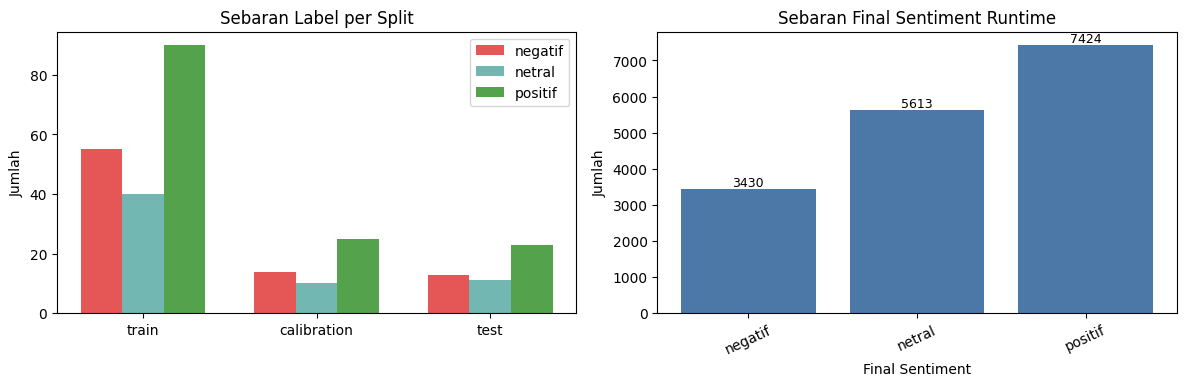

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if config.TRAINING_DATASET_WITH_SPLIT_PATH.exists():
    split_df = pl.read_parquet(config.TRAINING_DATASET_WITH_SPLIT_PATH)
    grouped = split_df.group_by(["split", "sentiment_label"]).len().to_dicts()
    splits = ["train", "calibration", "test"]
    x = range(len(splits))
    width = 0.24
    colors = {"negatif": "#e45756", "netral": "#72b7b2", "positif": "#54a24b"}
    for offset, label in enumerate(LABEL_ORDER):
        values = [
            next(
                (
                    int(row["len"])
                    for row in grouped
                    if row["split"] == split and row["sentiment_label"] == label
                ),
                0,
            )
            for split in splits
        ]
        positions = [item + (offset - 1) * width for item in x]
        axes[0].bar(positions, values, width=width, label=label, color=colors[label])
    axes[0].set_title("Sebaran Label per Split")
    axes[0].set_xticks(list(x), splits)
    axes[0].set_ylabel("Jumlah")
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "Split dataset belum tersedia", ha="center", va="center")
    axes[0].set_axis_off()

if predictions_path.exists():
    predictions_df = pl.read_parquet(predictions_path)
    final_counts = counts_from_series(predictions_df["final_sentiment"].to_list())
    plot_count_bar(
        axes[1],
        final_counts,
        "Sebaran Final Sentiment Runtime",
        xlabel="Final Sentiment",
        order=LABEL_ORDER,
    )
else:
    axes[1].text(0.5, 0.5, "Runtime predictions belum tersedia", ha="center", va="center")
    axes[1].set_axis_off()

fig.tight_layout(pad=1.2)
plt.show()


## 9. Sebaran Metadata Runtime per Sentiment

Visualisasi ini memakai output runtime bila tersedia. Jika runtime predictions belum ada, notebook memakai `raw_candidate_schema.csv` sebagai fallback. Setiap bar ditumpuk berdasarkan sentiment.

Sumber metadata: runtime predictions: E:\School\tugas-akhir\project\outputs\artifacts\experiments\hybrid_indobert_socal_manual\runtime\scenario_without_llm_predictions.parquet
Jumlah row: 16,467
Kolom sentiment: final_sentiment


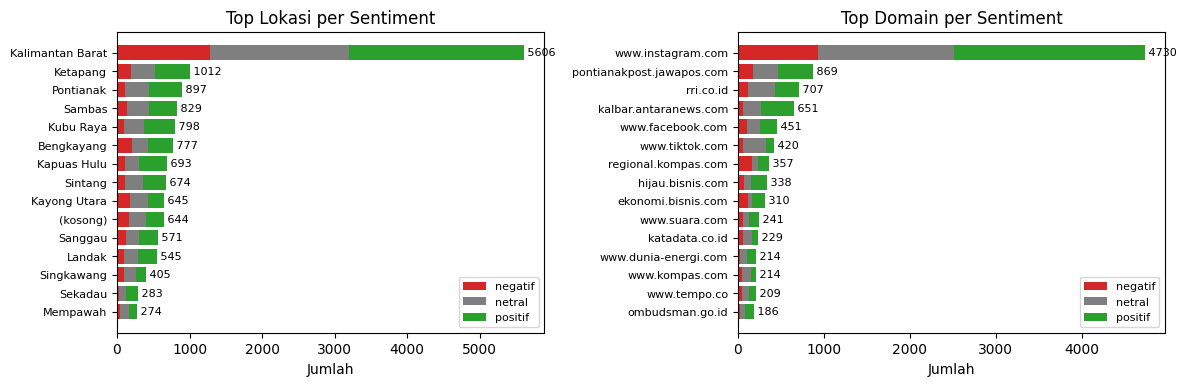

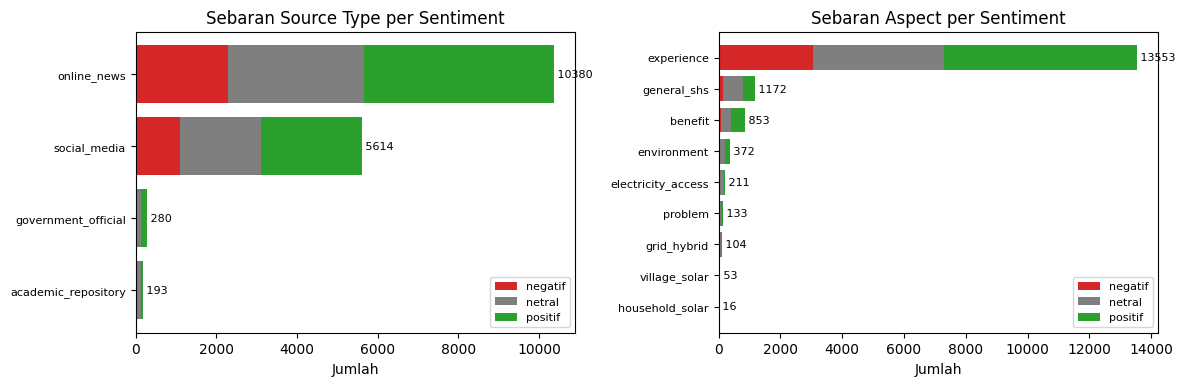

In [22]:
from urllib.parse import urlparse


def load_metadata_distribution_df():
    if predictions_path.exists():
        return pl.read_parquet(predictions_path), f"runtime predictions: {predictions_path}"
    if config.RAW_CANDIDATE_SCHEMA_PATH.exists():
        return pl.read_csv(config.RAW_CANDIDATE_SCHEMA_PATH, infer_schema_length=10_000, ignore_errors=True), f"raw candidate: {config.RAW_CANDIDATE_SCHEMA_PATH}"
    return None, ""


def values_for_distribution(df, column):
    if column not in df.columns:
        return []
    return [str(value or "").strip() or "(kosong)" for value in df[column].to_list()]


def sentiment_values_for_distribution(df):
    if "final_sentiment" in df.columns:
        values = values_for_distribution(df, "final_sentiment")
        if any(value in LABEL_ORDER for value in values):
            return values, "final_sentiment"
    if "sentiment_label" in df.columns:
        values = [
            value if value in LABEL_ORDER else "(tanpa sentiment)"
            for value in values_for_distribution(df, "sentiment_label")
        ]
        return values, "sentiment_label"
    if "bert_label" in df.columns:
        values = values_for_distribution(df, "bert_label")
        if any(value in LABEL_ORDER for value in values):
            return values, "bert_label"
    return ["(tanpa sentiment)"] * df.height, "(tanpa sentiment)"


def domain_values(df):
    if "raw_domain" in df.columns:
        values = values_for_distribution(df, "raw_domain")
        if any(value != "(kosong)" for value in values):
            return values
    if "domain" in df.columns:
        values = values_for_distribution(df, "domain")
        if any(value != "(kosong)" for value in values):
            return values
    if "source_url" not in df.columns:
        return []
    domains = []
    for url in df["source_url"].to_list():
        parsed = urlparse(str(url or ""))
        domains.append(parsed.netloc.lower() or "(kosong)")
    return domains


def sentiment_order(values):
    extras = sorted({value for value in values if value not in LABEL_ORDER})
    return [label for label in LABEL_ORDER if label in values] + extras


def plot_top_count_by_sentiment_barh(ax, category_values, sentiment_values, title, top_n=15):
    if not category_values or not sentiment_values:
        ax.text(0.5, 0.5, "Data tidak tersedia", ha="center", va="center")
        ax.set_axis_off()
        return

    totals = {}
    grouped = {}
    for category, sentiment in zip(category_values, sentiment_values):
        category = str(category or "").strip() or "(kosong)"
        sentiment = str(sentiment or "").strip() or "(tanpa sentiment)"
        totals[category] = totals.get(category, 0) + 1
        grouped.setdefault(category, {})[sentiment] = grouped.setdefault(category, {}).get(sentiment, 0) + 1

    if not totals:
        ax.text(0.5, 0.5, "Data tidak tersedia", ha="center", va="center")
        ax.set_axis_off()
        return

    ordered = sorted(totals.items(), key=lambda item: (-item[1], item[0]))[:top_n]
    labels = [item[0] for item in ordered][::-1]
    y_positions = list(range(len(labels)))
    left = [0] * len(labels)
    colors = {
        "negatif": "#d62728",
        "netral": "#7f7f7f",
        "positif": "#2ca02c",
        "(tanpa sentiment)": "#bdbdbd",
    }

    for sentiment in sentiment_order(sentiment_values):
        numbers = [grouped.get(label, {}).get(sentiment, 0) for label in labels]
        if not any(numbers):
            continue
        ax.barh(
            y_positions,
            numbers,
            left=left,
            label=sentiment,
            color=colors.get(sentiment, "#4c78a8"),
        )
        left = [current + value for current, value in zip(left, numbers)]

    ax.set_yticks(y_positions, labels)
    ax.set_title(title)
    ax.set_xlabel("Jumlah")
    ax.tick_params(axis="y", labelsize=8)
    for index, total in enumerate(left):
        ax.text(total, index, f" {total}", va="center", fontsize=8)
    ax.legend(loc="best", fontsize=8)


metadata_df, metadata_source = load_metadata_distribution_df()
if metadata_df is None:
    print("Dataset metadata belum tersedia. Jalankan build raw candidate atau runtime tanpa LLM lebih dulu.")
else:
    sentiment_values, sentiment_column = sentiment_values_for_distribution(metadata_df)
    print(f"Sumber metadata: {metadata_source}")
    print(f"Jumlah row: {metadata_df.height:,}")
    print(f"Kolom sentiment: {sentiment_column}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_top_count_by_sentiment_barh(
        axes[0],
        values_for_distribution(metadata_df, "location"),
        sentiment_values,
        "Top Lokasi per Sentiment",
        top_n=15,
    )
    plot_top_count_by_sentiment_barh(
        axes[1],
        domain_values(metadata_df),
        sentiment_values,
        "Top Domain per Sentiment",
        top_n=15,
    )
    fig.tight_layout(pad=1.2)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_top_count_by_sentiment_barh(
        axes[0],
        values_for_distribution(metadata_df, "source_type"),
        sentiment_values,
        "Sebaran Source Type per Sentiment",
        top_n=15,
    )
    plot_top_count_by_sentiment_barh(
        axes[1],
        values_for_distribution(metadata_df, "aspect"),
        sentiment_values,
        "Sebaran Aspect per Sentiment",
        top_n=15,
    )
    fig.tight_layout(pad=1.2)
    plt.show()



## 10. Review, Fusion Action, Confidence, dan Uncertainty

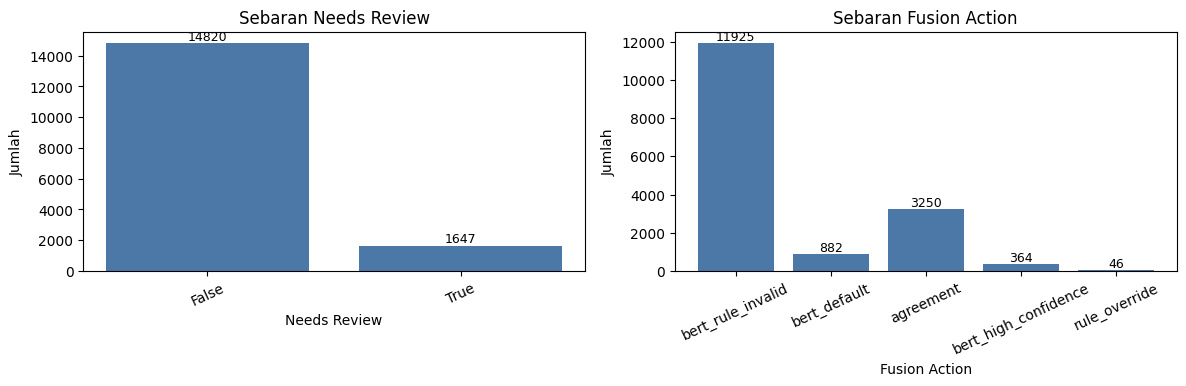

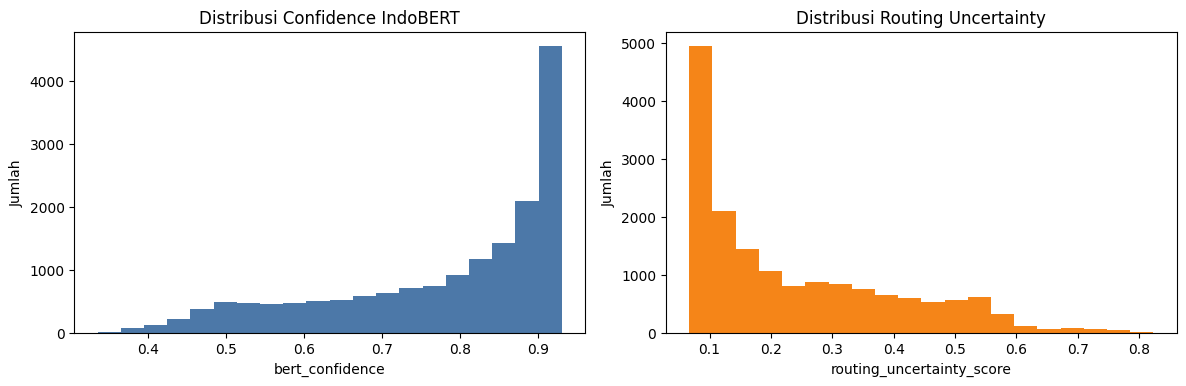

In [23]:
if predictions_path.exists():
    predictions_df = pl.read_parquet(predictions_path)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    needs_review_counts = counts_from_series(predictions_df["needs_review"].to_list())
    fusion_action_counts = counts_from_series(predictions_df["fusion_action"].to_list())
    plot_count_bar(
        axes[0],
        needs_review_counts,
        "Sebaran Needs Review",
        xlabel="Needs Review",
        order=["False", "True"],
    )
    plot_count_bar(
        axes[1],
        fusion_action_counts,
        "Sebaran Fusion Action",
        xlabel="Fusion Action",
    )
    fig.tight_layout(pad=1.2)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(predictions_df["bert_confidence"].to_list(), bins=20, color="#4c78a8")
    axes[0].set_title("Distribusi Confidence IndoBERT")
    axes[0].set_xlabel("bert_confidence")
    axes[0].set_ylabel("Jumlah")

    axes[1].hist(predictions_df["routing_uncertainty_score"].to_list(), bins=20, color="#f58518")
    axes[1].set_title("Distribusi Routing Uncertainty")
    axes[1].set_xlabel("routing_uncertainty_score")
    axes[1].set_ylabel("Jumlah")
    fig.tight_layout(pad=1.2)
    plt.show()
else:
    print("Runtime predictions belum tersedia:", predictions_path)


## 11. Scatter Chart Sebaran Runtime

Scatter chart ini membantu membaca pola confidence, uncertainty, margin, entropy, final sentiment, dan aksi fusion pada output runtime tanpa LLM.

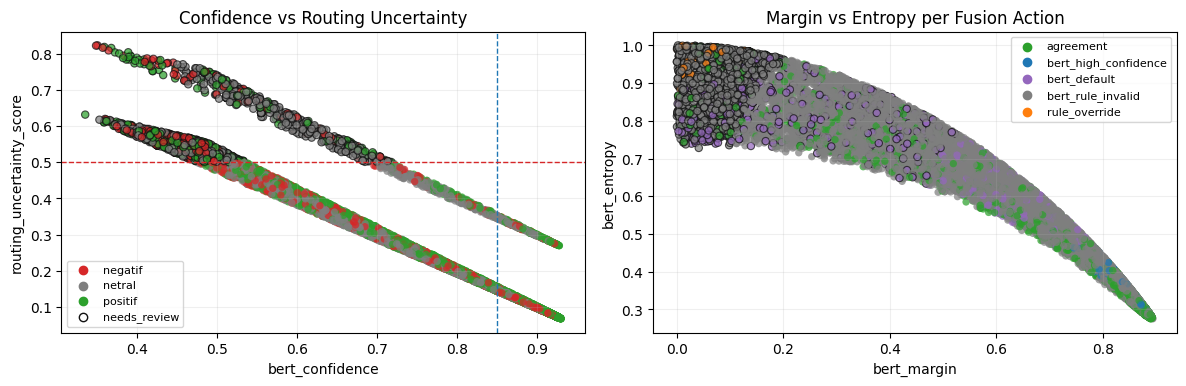

In [24]:
if predictions_path.exists():
    predictions_df = pl.read_parquet(predictions_path)

    required_scatter_columns = [
        "bert_confidence",
        "routing_uncertainty_score",
        "bert_margin",
        "bert_entropy",
        "final_sentiment",
        "fusion_action",
        "needs_review",
    ]
    missing_scatter_columns = [col for col in required_scatter_columns if col not in predictions_df.columns]

    if missing_scatter_columns:
        print(f"Kolom scatter belum tersedia: {missing_scatter_columns}")
    else:
        sentiment_colors = {
            "negatif": "#d62728",
            "netral": "#7f7f7f",
            "positif": "#2ca02c",
        }
        fusion_colors = {
            "agreement": "#2ca02c",
            "bert_high_confidence": "#1f77b4",
            "bert_default": "#9467bd",
            "bert_rule_invalid": "#7f7f7f",
            "rule_override": "#ff7f0e",
        }

        confidence_values = predictions_df["bert_confidence"].cast(pl.Float64).to_list()
        uncertainty_values = predictions_df["routing_uncertainty_score"].cast(pl.Float64).to_list()
        margin_values = predictions_df["bert_margin"].cast(pl.Float64).to_list()
        entropy_values = predictions_df["bert_entropy"].cast(pl.Float64).to_list()
        final_labels = predictions_df["final_sentiment"].to_list()
        fusion_actions = predictions_df["fusion_action"].to_list()
        needs_review_values = predictions_df["needs_review"].to_list()

        sentiment_point_colors = [sentiment_colors.get(label, "#333333") for label in final_labels]
        fusion_point_colors = [fusion_colors.get(action, "#333333") for action in fusion_actions]
        review_edge_colors = ["#111111" if value else "none" for value in needs_review_values]
        review_line_widths = [0.8 if value else 0.0 for value in needs_review_values]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].scatter(
            confidence_values,
            uncertainty_values,
            c=sentiment_point_colors,
            edgecolors=review_edge_colors,
            linewidths=review_line_widths,
            alpha=0.72,
            s=28,
        )
        axes[0].axvline(
            fusion_policy.get("high_confidence_threshold", 0.85) if fusion_policy else 0.85,
            color="#1f77b4",
            linestyle="--",
            linewidth=1,
        )
        axes[0].axhline(
            fusion_policy.get("uncertainty_review_threshold", 0.5) if fusion_policy else 0.5,
            color="#d62728",
            linestyle="--",
            linewidth=1,
        )
        axes[0].set_title("Confidence vs Routing Uncertainty")
        axes[0].set_xlabel("bert_confidence")
        axes[0].set_ylabel("routing_uncertainty_score")
        axes[0].grid(alpha=0.2)

        for label, color in sentiment_colors.items():
            axes[0].scatter([], [], c=color, label=label, s=36)
        axes[0].scatter([], [], facecolors="white", edgecolors="#111111", label="needs_review", s=36)
        axes[0].legend(loc="best", fontsize=8)

        axes[1].scatter(
            margin_values,
            entropy_values,
            c=fusion_point_colors,
            edgecolors=review_edge_colors,
            linewidths=review_line_widths,
            alpha=0.72,
            s=28,
        )
        axes[1].set_title("Margin vs Entropy per Fusion Action")
        axes[1].set_xlabel("bert_margin")
        axes[1].set_ylabel("bert_entropy")
        axes[1].grid(alpha=0.2)

        for action, color in fusion_colors.items():
            axes[1].scatter([], [], c=color, label=action, s=36)
        axes[1].legend(loc="best", fontsize=8)

        fig.tight_layout(pad=1.2)
        plt.show()
else:
    print("Prediksi runtime belum tersedia. Jalankan tahap run-without-llm lebih dulu.")

